# OOD Discriminability via Classification

This notebook trains simple binary classifiers to measure how easily different out-of-distribution (OOD) datasets can be distinguished from the in-distribution (ID) Craigslist data.

For each OOD split, we:
- Build a balanced dataset of ID vs that OOD set.
- Apply a standard preprocessing pipeline (numeric standardization + categorical one-hot encoding).
- Train a logistic regression classifier.
- Report AUROC, AUPRC, accuracy, and F1 on a held-out test split.

This classification difficulty is a proxy for how strong each OOD shift is in the feature space and will later be compared with epistemic uncertainty signals.

In [8]:
# This cell imports libraries and defines paths and OOD dataset files.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
)

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "datasets"

# ID-only cleaned dataset (produced by scripts/make_ood_splits.py)
ID_PATH = DATA_DIR / "craigslist_cleaned_id_only.csv"

OOD_FILES = {
    "ood_tail_mpy_high": DATA_DIR / "craigslist_ood_tail_mpy_high.csv",
    "ood_tail_odo_high": DATA_DIR / "craigslist_ood_tail_odo_high.csv",
    "ood_tail_year_old": DATA_DIR / "craigslist_ood_tail_year_old.csv",
    "ood_tail_multi": DATA_DIR / "craigslist_ood_tail_multi.csv",
    "ood_rare_manufacturers": DATA_DIR / "craigslist_ood_rare_manufacturers.csv",
    "ood_geo_fl_tx": DATA_DIR / "craigslist_ood_geo_fl_tx.csv",
}

RANDOM_STATE = 42
MAX_PER_CLASS = 30000  # upper cap per class to keep runs manageable


In [9]:
# This cell defines candidate feature lists and a helper to select usable columns.

# Candidate numeric and categorical features based on the cleaned dataset schema.
CANDIDATE_NUMERIC_COLS = [
    "year",
    "odometer",
    "mileage_per_year",
    "lat",
    "long",
]

CANDIDATE_CATEGORICAL_COLS = [
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "state",
]

def get_feature_columns(df: pd.DataFrame):
    """Return lists of numeric and categorical feature columns that exist in the DataFrame."""
    numeric_cols = [c for c in CANDIDATE_NUMERIC_COLS if c in df.columns]
    cat_cols = [c for c in CANDIDATE_CATEGORICAL_COLS if c in df.columns]
    return numeric_cols, cat_cols


In [10]:
# This cell defines helpers to load ID/OOD data and build a balanced combined dataset.

def load_id_and_ood_frames(ood_name: str, max_per_class: int = MAX_PER_CLASS) -> pd.DataFrame:
    """Load ID and OOD CSVs, label them, and return a balanced combined DataFrame.

    The returned frame contains an 'is_ood' column (0 for ID, 1 for OOD) and is shuffled.
    """
    ood_path = OOD_FILES[ood_name]
    df_id = pd.read_csv(ID_PATH)
    df_ood = pd.read_csv(ood_path)

    df_id["is_ood"] = 0
    df_ood["is_ood"] = 1

    # Keep only columns that are shared between ID and OOD (including the label).
    common_cols = sorted(set(df_id.columns) & set(df_ood.columns))
    df_id = df_id[common_cols]
    df_ood = df_ood[common_cols]

    # Balance the classes by subsampling the majority class.
    n_id = len(df_id)
    n_ood = len(df_ood)
    n_per_class = min(n_id, n_ood, max_per_class)
    if n_per_class == 0:
        raise ValueError(
            f"No samples available for OOD '{ood_name}': n_id={n_id}, n_ood={n_ood}. "
            "Ensure the CSVs were regenerated and have rows after masking."
        )


    df_id_sample = df_id.sample(n=n_per_class, random_state=RANDOM_STATE)
    df_ood_sample = df_ood.sample(n=n_per_class, random_state=RANDOM_STATE)

    df_combined = pd.concat([df_id_sample, df_ood_sample], ignore_index=True)
    df_combined = df_combined.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

    return df_combined


In [11]:
# This cell creates the preprocessing + classifier pipeline and a training/evaluation helper.

def make_preprocessing_pipeline(df: pd.DataFrame):
    """Build a sklearn Pipeline with standardization for numerics and one-hot encoding for categoricals."""
    numeric_cols, cat_cols = get_feature_columns(df)
    if not numeric_cols and not cat_cols:
        raise ValueError("No usable feature columns found in the data.")

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )

    clf = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        n_jobs=-1,
    )

    model = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("clf", clf),
        ]
    )

    feature_info = {
        "numeric_cols": numeric_cols,
        "categorical_cols": cat_cols,
    }

    return model, feature_info


def train_and_evaluate_ood_classifier(
    ood_name: str,
    max_per_class: int = MAX_PER_CLASS,
    test_size: float = 0.2,
    val_size: float = 0.2,
):
    """Train a binary classifier for a given OOD dataset and report validation/test metrics.

    Returns the trained sklearn Pipeline and a dictionary of metrics and predictions.
    """
    df = load_id_and_ood_frames(ood_name, max_per_class=max_per_class)
    y = df["is_ood"].values
    X = df.drop(columns=["is_ood"])

    # First split into train+val and test.
    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    # Split temp into train and validation.
    val_fraction_of_temp = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=val_fraction_of_temp,
        stratify=y_temp,
        random_state=RANDOM_STATE,
    )

    model, feature_info = make_preprocessing_pipeline(df)

    model.fit(X_train, y_train)

    def eval_split(X_split, y_split):
        """Compute metrics for a given split using the current model."""
        y_prob = model.predict_proba(X_split)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        metrics = {
            "n": int(len(y_split)),
            "auroc": roc_auc_score(y_split, y_prob),
            "auprc": average_precision_score(y_split, y_prob),
            "accuracy": accuracy_score(y_split, y_pred),
            "f1": f1_score(y_split, y_pred),
        }
        return metrics, y_prob, y_pred

    val_metrics, y_val_prob, y_val_pred = eval_split(X_val, y_val)
    test_metrics, y_test_prob, y_test_pred = eval_split(X_test, y_test)

    results = {
        "ood_name": ood_name,
        "n_total": int(len(df)),
        "feature_info": feature_info,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "y_test_prob": y_test_prob,
        "y_test_true": y_test,
    }

    return model, results


In [12]:
# This optional cell runs a single example experiment and prints its metrics.

example_ood = "ood_rare_manufacturers"

model_example, results_example = train_and_evaluate_ood_classifier(example_ood)

print(f"Example OOD: {example_ood}")
print("Validation metrics:", results_example["val_metrics"])
print("Test metrics:", results_example["test_metrics"])


Example OOD: ood_rare_manufacturers
Validation metrics: {'n': 9588, 'auroc': 0.7878245587195369, 'auprc': 0.7984907348129593, 'accuracy': 0.6953483521068001, 'f1': 0.6959508691579057}
Test metrics: {'n': 9588, 'auroc': 0.7912279185722523, 'auprc': 0.799364213761153, 'accuracy': 0.700354609929078, 'f1': 0.6998850934921133}



=== Running OOD experiment: ood_tail_mpy_high ===

=== Running OOD experiment: ood_tail_odo_high ===

=== Running OOD experiment: ood_tail_year_old ===

=== Running OOD experiment: ood_tail_multi ===

=== Running OOD experiment: ood_rare_manufacturers ===

=== Running OOD experiment: ood_geo_fl_tx ===


,ood_name,n_total,val_auroc,test_auroc,test_auprc,test_accuracy,test_f1
2,ood_tail_year_old,60000,0.879828,0.880967,0.885890,0.790083,0.789821
3,ood_tail_multi,60000,0.846912,0.855260,0.861187,0.763833,0.767667
1,ood_tail_odo_high,60000,0.845170,0.850475,0.854764,0.757833,0.761020
0,ood_tail_mpy_high,60000,0.806853,0.810391,0.815398,0.718333,0.732510
4,ood_rare_manufacturers,47938,0.787825,0.791228,0.799364,0.700355,0.699885
5,ood_geo_fl_tx,51040,0.666046,0.669666,0.697349,0.615204,0.603793


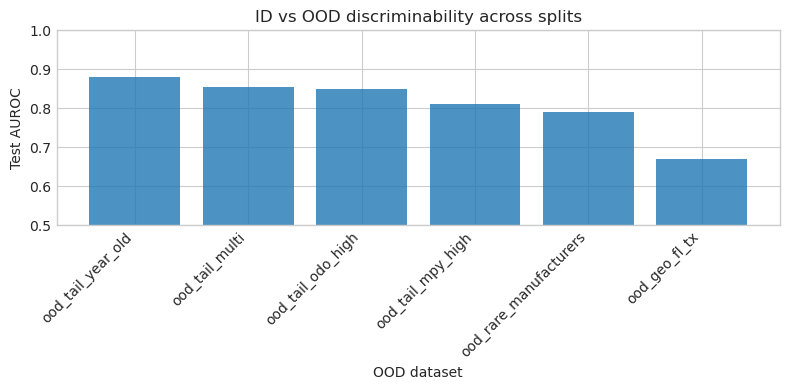

In [13]:
# This cell runs the classifier experiment for all OOD datasets,
# then builds a comparison DataFrame and a summary visualization.

all_results = []
results_by_ood = {}

for ood_name in OOD_FILES.keys():
    print(f"\n=== Running OOD experiment: {ood_name} ===")
    _, res = train_and_evaluate_ood_classifier(ood_name)
    results_by_ood[ood_name] = res
    all_results.append(
        {
            "ood_name": ood_name,
            "n_total": res["n_total"],
            "val_auroc": res["val_metrics"]["auroc"],
            "test_auroc": res["test_metrics"]["auroc"],
            "test_auprc": res["test_metrics"]["auprc"],
            "test_accuracy": res["test_metrics"]["accuracy"],
            "test_f1": res["test_metrics"]["f1"],
        }
    )

metrics_df = pd.DataFrame(all_results).sort_values("test_auroc", ascending=False)
display(metrics_df)

plt.figure(figsize=(8, 4))
plt.bar(metrics_df["ood_name"], metrics_df["test_auroc"], color="tab:blue", alpha=0.8)
plt.ylabel("Test AUROC")
plt.xlabel("OOD dataset")
plt.title("ID vs OOD discriminability across splits")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.5, 1.0)
plt.tight_layout()


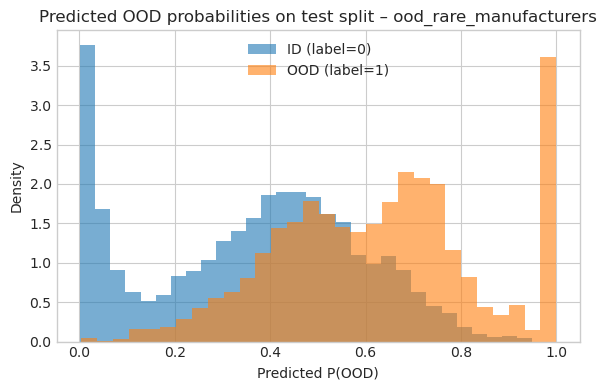

In [14]:
# This cell visualizes predicted OOD probabilities on the test split for a selected OOD type.

def plot_test_prob_hist(results, ood_name: str):
    """Plot histograms of predicted OOD probabilities for ID and OOD test examples."""
    y_true = results["y_test_true"]
    y_prob = results["y_test_prob"]

    plt.figure(figsize=(6, 4))
    plt.hist(
        y_prob[y_true == 0],
        bins=30,
        alpha=0.6,
        label="ID (label=0)",
        density=True,
    )
    plt.hist(
        y_prob[y_true == 1],
        bins=30,
        alpha=0.6,
        label="OOD (label=1)",
        density=True,
    )
    plt.xlabel("Predicted P(OOD)")
    plt.ylabel("Density")
    plt.title(f"Predicted OOD probabilities on test split – {ood_name}")
    plt.legend()
    plt.tight_layout()


# Example: visualize results for the example OOD experiment run above.
plot_test_prob_hist(results_example, example_ood)


## Interpreting the classification metrics

- **AUROC \~0.5–0.6**: ID and this OOD set are almost indistinguishable for this classifier and feature set; the shift is very subtle.
- **AUROC 0.6–0.8**: The OOD set is detectably different but not trivially so; this is a good regime for testing epistemic methods.
- **AUROC 0.8–0.9**: The shift is clear and fairly easy to detect.
- **AUROC > 0.9**: The classifier can almost perfectly separate ID vs OOD; this indicates a strong distribution shift, and high epistemic scores here are expected.

In later analysis, you can compare these supervised AUROC values against the AUROC obtained when using epistemic uncertainty scores (e.g., predictive variance or ensemble disagreement) as an unsupervised OOD detector on the same ID vs OOD splits.